# House Price Prediction using Machine Learning

This project predicts house prices using Linear Regression on a Kaggle dataset.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
import pandas as pd

df = pd.read_csv("/train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
features = [
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "GrLivArea",
    "FullBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "GarageCars"
]

df = df[features + ["SalePrice"]]

df = df.dropna()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (1460, 10)


In [17]:
X = df[features]
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1168
Testing samples: 292


In [18]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression
------------------
MAE : 25573.63
RMSE: 40069.53
R²  : 0.7907


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------
MAE : 19187.05
RMSE: 29344.86
R²  : 0.8877


In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,25573.628819,40069.530216,0.790678
1,Random Forest,19187.046007,29344.859640,0.887733


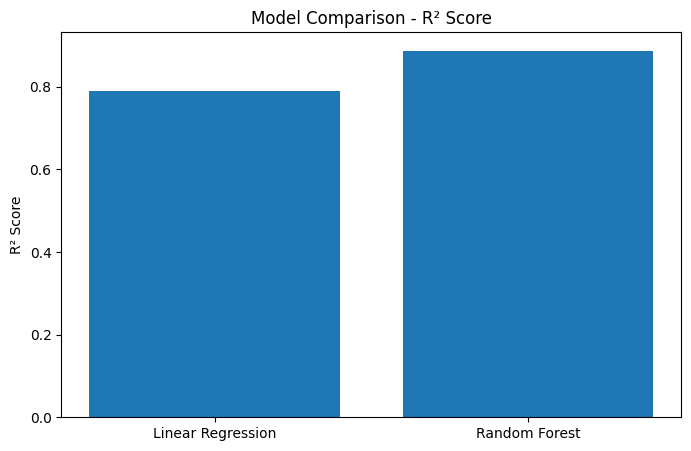

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["R2"])

plt.ylabel("R² Score")
plt.title("Model Comparison - R² Score")

plt.show()

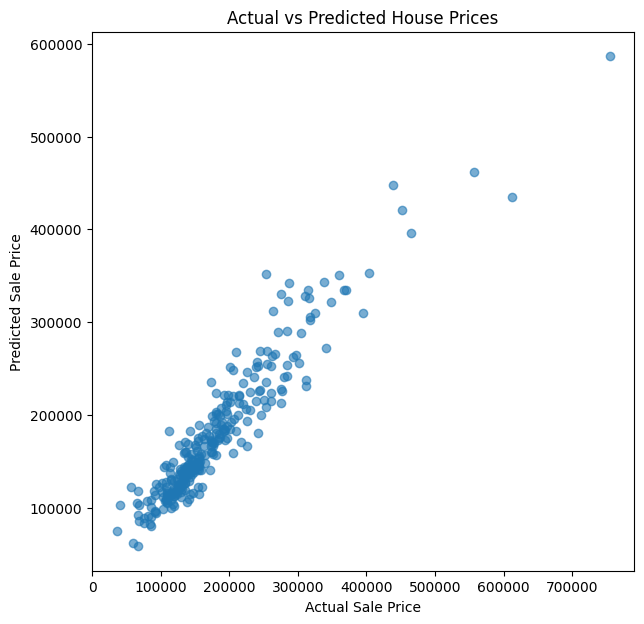

In [22]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [26]:
rf_model.fit(X_train, y_train)

print("✅ Model is ready!")


✅ Model is ready!


In [27]:
sample_house = [[
    845,
    7,
    5,
    2003,
    1710,
    2,
    3,
    8,
    2
]]

prediction = rf_model.predict(sample_house)

print("Predicted House Price: $", round(prediction[0], 2))

Predicted House Price: $ 148677.45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [28]:
sample_house = pd.DataFrame([[
    845,
    7,
    5,
    2003,
    1710,
    2,
    3,
    8,
    2
]], columns=features)

prediction = rf_model.predict(sample_house)

print("Predicted House Price: $", round(prediction[0], 2))

Predicted House Price: $ 148677.45


In [29]:
def predict_house_price(
    lot_area,
    overall_qual,
    overall_cond,
    year_built,
    gr_liv_area,
    full_bath,
    bedroom_abv_gr,
    tot_rms_abv_grd,
    garage_cars
):
    house = pd.DataFrame([[
        lot_area,
        overall_qual,
        overall_cond,
        year_built,
        gr_liv_area,
        full_bath,
        bedroom_abv_gr,
        tot_rms_abv_grd,
        garage_cars
    ]], columns=features)

    prediction = rf_model.predict(house)

    return round(prediction[0], 2)

In [30]:
price = predict_house_price(
    lot_area=845,
    overall_qual=7,
    overall_cond=5,
    year_built=2003,
    gr_liv_area=1710,
    full_bath=2,
    bedroom_abv_gr=3,
    tot_rms_abv_grd=8,
    garage_cars=2
)

print("🏠 Predicted House Price: $", price)

🏠 Predicted House Price: $ 148677.45


In [31]:
lot_area = float(input("Enter Lot Area: "))
overall_qual = float(input("Enter Overall Quality (1-10): "))
overall_cond = float(input("Enter Overall Condition (1-10): "))
year_built = int(input("Enter Year Built: "))
gr_liv_area = float(input("Enter Living Area (sq ft): "))
full_bath = float(input("Enter Number of Full Bathrooms: "))
bedroom_abv_gr = int(input("Enter Number of Bedrooms: "))
tot_rms_abv_grd = int(input("Enter Total Rooms: "))
garage_cars = float(input("Enter Garage Capacity (cars): "))

price = predict_house_price(
    lot_area,
    overall_qual,
    overall_cond,
    year_built,
    gr_liv_area,
    full_bath,
    bedroom_abv_gr,
    tot_rms_abv_grd,
    garage_cars
)

print("\n🏠 Predicted House Price: $", price)

Enter Lot Area: 845
Enter Overall Quality (1-10): 7
Enter Overall Condition (1-10): 5
Enter Year Built: 2003
Enter Living Area (sq ft): 1710
Enter Number of Full Bathrooms: 2
Enter Number of Bedrooms: 3
Enter Total Rooms: 8
Enter Garage Capacity (cars): 2

🏠 Predicted House Price: $ 148677.45


In [32]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

print("✅ Model saved successfully!")


✅ Model saved successfully!


In [33]:
import os

print(os.path.exists("house_price_model.pkl"))

True


In [34]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>